# E4: Mental Model Transfer

**Research question:** Does repeated exposure to NLEs help a judge build an accurate mental model of the XGBoost model, enabling better predictions on new instances?

## Design

Sliding window approach — for each test instance:
1. **Learning phase**: Judge sees N=5 chronologically preceding instances with features, SHAP, metrics, prediction, and true outcome (with or without NLEs)
2. **Test phase**: Judge sees a new instance (features + SHAP + metrics + prediction only, NO NLE, NO answer) and must predict the error bucket

**Why chronological predecessors?** This simulates a realistic user scenario: someone who has been monitoring the model's recent predictions and outcomes, building intuition over time. The 5 most recent instances provide temporal context (e.g., seasonal patterns, recent model behavior) rather than random examples.

| Condition | Features | SHAP (X) | Metrics (T) | Training NLEs (E) | Test NLE |
|-----------|:--:|:--:|:--:|:--:|:--:|
| Baseline | ✓ | ✓ | ✓ | ✗ | ✗ |
| E | ✓ | ✓ | ✓ | ✓ | ✗ |

Features, SHAP values, and metrics are always included — they are essential context, and the NLE was generated from them. The test instance is identical across conditions — only the training examples differ.

**2×2 generator×judge design:** For the E condition, training NLEs come from either GPT-4o or DeepSeek-R1, evaluated by both judges (4 combinations). Baseline has no generator dimension — just 2 judges.

## Judgment count

- Test positions: indices 5–59 (55 instances, each using 5 predecessors as training)
- First 5 instances (0–4) serve only as training data — no predecessors available for them
- Baseline: N × 2 judges
- E condition: N × 2 generators × 2 judges
- **Pilot (N=15):** 15×2 + 15×2×2 = 30 + 60 = **90**
- **Full (N=55):** 55×2 + 55×2×2 = 110 + 220 = **330**

## Hypotheses

- H4a: Judges exposed to NLEs in training do NOT perform better (quality-usefulness gap extends to mental model formation)
- H4b: NLEs slightly help by providing a coherent narrative framework for the model's behavior

## Key comparison: E4 vs E1

- If E4_Baseline > E1_Baseline: learning phase helps baseline performance (in-context learning works)
- If E4_E ≈ E1_E+X+T: NLE harm persists even with learning context
- If E4_E > E1_E+X+T: NLEs help in learning but not in zero-shot

## Statistical plan

- **Primary:** Accuracy (% correct error bucket) by condition
- **Key contrast:** Baseline vs E (does NLE in training help?)
- **Secondary:** Confidence analysis, confusion matrix
- **95% CI:** Wilson interval
- **Pilot (N=15) → effect size → power check → Full (N=55)**

## 0. Setup

In [1]:
import os
import sys
import asyncio
import json
import re
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
import matplotlib.pyplot as plt

import utils

# ── Toggle: pilot vs full ──────────────────────────────────────────
PILOT_MODE = False   # Set False for full experiment
N = 15 if PILOT_MODE else 55  # 55 test positions available (indices 5-59)
N_TRAIN = 5  # Number of preceding instances as training examples
RANDOM_SEED = 42
# ───────────────────────────────────────────────────────────────────

# Override from run_all.py script
if os.environ.get('EXPERIMENT_N'):
    N = int(os.environ['EXPERIMENT_N'])
    PILOT_MODE = N < 55

RESULTS_DIR = utils.RESULTS_DIR / 'E4'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 2 conditions: with/without NLE in training examples
CONDITIONS = [
    {'name': 'Baseline', 'nle': False},
    {'name': 'E',        'nle': True},
]

VALID_BUCKETS = {'small', 'medium', 'large', 'very_large'}

mode_str = f'PILOT (N={N})' if PILOT_MODE else f'FULL (N={N})'
print(f'E4 Mental Model Transfer — {mode_str}')
print(f'Conditions: {[c["name"] for c in CONDITIONS]}')

E4 Mental Model Transfer — FULL (N=55)
Conditions: ['Baseline', 'E']


## 1. Load data

In [2]:
# Load test instances with SHAP values
model = utils.load_xgb_model()
test_df = utils.build_test_with_shap(model)
test_df['error_bucket'] = test_df['pct_error'].apply(utils.pct_error_to_bucket)

# Load NLE cache (120 rows: 60 × 2 generators)
nle_cache = utils.load_nle_cache()

print(f'Test instances: {len(test_df)}')
print(f'NLE cache: {len(nle_cache)} rows ({nle_cache["generator"].value_counts().to_dict()})')
print(f'Error bucket distribution:')
print(test_df['error_bucket'].value_counts())

# Available test positions: indices N_TRAIN through 59
all_test_positions = list(range(N_TRAIN, len(test_df)))
print(f'\nAvailable test positions: {len(all_test_positions)} (indices {all_test_positions[0]}-{all_test_positions[-1]})')

# Sample N test positions (stratified by error_bucket of test instance)
if N < len(all_test_positions):
    test_pos_df = test_df.iloc[all_test_positions].copy()
    test_pos_df['position'] = all_test_positions
    sampled_positions = []
    for bucket, group in test_pos_df.groupby('error_bucket'):
        n_from = max(1, round(N * len(group) / len(test_pos_df)))
        sampled = group.sample(min(len(group), n_from), random_state=RANDOM_SEED)
        sampled_positions.extend(sampled['position'].tolist())
    if len(sampled_positions) < N:
        remaining = [p for p in all_test_positions if p not in sampled_positions]
        extra = np.random.default_rng(RANDOM_SEED).choice(remaining, size=N - len(sampled_positions), replace=False)
        sampled_positions.extend(extra.tolist())
    sampled_positions = sorted(sampled_positions[:N])
else:
    sampled_positions = all_test_positions

print(f'\nUsing {len(sampled_positions)} test positions: {sampled_positions}')
print('Test instance bucket distribution:', test_df.iloc[sampled_positions]['error_bucket'].value_counts().to_dict())

Test instances: 60
NLE cache: 120 rows ({'gpt': 60, 'deepseek': 60})
Error bucket distribution:
error_bucket
medium        29
large         16
small         12
very_large     3
Name: count, dtype: int64

Available test positions: 55 (indices 5-59)

Using 55 test positions: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
Test instance bucket distribution: {'medium': 25, 'large': 15, 'small': 12, 'very_large': 3}


## 2. Build judge prompts

In [3]:
JUDGE_SYSTEM = """You are evaluating a machine learning model's prediction accuracy for a time series forecasting task.
You have limited background in machine learning and statistics — you understand basic concepts but are not an expert.

You will first see several example predictions from the most recent consecutive weeks, with their KNOWN error outcomes. Study these examples carefully to understand the model's behavior patterns and recent trends. Then you will evaluate a NEW prediction for the following week.

Your task: Based on the patterns you observed in the examples and the information about the new instance, classify the new prediction's likely error bucket.

Important: Think carefully about each specific instance. Consider all the details provided — feature values, patterns, SHAP importances, and any explanations. Do not default to a "safe" middle-ground answer. Each prediction has a specific error magnitude; use the evidence from the examples to determine what it is.

Evaluation steps (think through each before giving your final answer):
1. Study the training examples — what patterns emerge in when the model has small vs large errors?
2. Compare the new instance's feature values and SHAP pattern to the training examples
3. Consider whether the model performance metrics suggest the model struggles in certain conditions
4. If explanations were provided in the training examples, you can use the reasoning patterns they illustrate
5. Apply the learned patterns to estimate the new instance's likely error magnitude

Error bucket definitions (based on absolute percentage error, regardless of whether the model over- or under-predicts):
- small: [0%, 5%) — absolute error less than 5%
- medium: [5%, 15%) — absolute error from 5% up to but not including 15%
- large: [15%, 30%) — absolute error from 15% up to but not including 30%
- very_large: [30%, +inf) — absolute error 30% or more

Confidence scale:
- 1 = Very uncertain about my assessment
- 2 = Somewhat uncertain
- 3 = Moderately confident
- 4 = Fairly confident
- 5 = Very certain about my assessment

You must respond with EXACTLY this JSON format and nothing else:
{
  "error_bucket": "<one of: small, medium, large, very_large>",
  "confidence": <integer from 1 to 5>,
  "reasoning": "<one sentence explaining your choice>"
}"""

DOMAIN_CONTEXT = """The following is about time series data with a single-step ahead prediction, where the model predicts the next value in the time series based on previous observations.
Data Domain: Energy Consumption
Dataset Description:
- The dataset contains 2,075,259 measurements from a house in Sceaux, France (near Paris), Dec 2006–Nov 2010.
- Recorded at one-minute resolution, then resampled weekly.
- Lag_1..Lag_7 (previous 7 weeks of consumption in kWh), ISO week number and number of public holidays per week were added as features.
- Target: weekly electricity consumption (kWh)."""


# Build NLE lookup: {(RowPos, generator) -> Explanation}
nle_lookup = {}
for _, nle_row in nle_cache.iterrows():
    nle_lookup[(int(nle_row['RowPos']), nle_row['generator'])] = nle_row['Explanation']


def format_training_example(row: pd.Series, example_num: int,
                            include_nle: bool, nle_text: str = '') -> str:
    """Format a single training example with known outcome."""
    parts = [f'--- Example {example_num} ---']
    parts.append(f'Week: {row["DateTime"]}')
    parts.append(f'Prediction: {row["prediction"]:.2f} kWh')
    parts.append(f'')
    parts.append(f'Features:')
    for f in utils.FEATURES:
        parts.append(f'  {f}: {row[f]:.2f}')
    parts.append(f'')
    parts.append(f'SHAP values:')
    shap_pairs = [(f, row[f'shap_{f}']) for f in utils.FEATURES]
    shap_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
    for feat, val in shap_pairs:
        parts.append(f'  {feat}: {val:+.3f}')
    parts.append(f'  Expected/base value: {row["shap_base_value"]:.3f}')

    if include_nle and nle_text:
        parts.append(f'')
        parts.append(f'Explanation of this prediction:')
        parts.append(nle_text)

    parts.append(f'')
    parts.append(f'KNOWN OUTCOME: True value = {row["True_Value"]:.2f} kWh, '
                 f'Absolute error = {abs(row["pct_error"]):.1f}%, '
                 f'Error bucket = {row["error_bucket"]}')
    return '\n'.join(parts)


def build_prompt(test_pos: int, condition: dict, generator: str = 'none') -> str:
    """Build the full E4 prompt: N training examples + 1 test instance."""
    train_indices = list(range(test_pos - N_TRAIN, test_pos))
    test_row = test_df.iloc[test_pos]

    parts = [DOMAIN_CONTEXT, '']
    parts.append(f'Model Used: XGBRegressor')
    parts.append(f'Model Performance:')
    parts.append(f'  - MAE: {utils.XGB_PERF["MAE"]:.3f}')
    parts.append(f'  - RMSE: {utils.XGB_PERF["RMSE"]:.3f}')
    parts.append(f'  - R²: {utils.XGB_PERF["R2"]:.3f}')
    parts.append(f'')
    parts.append(f'Below are the {N_TRAIN} most recent consecutive weekly predictions with known outcomes, in chronological order. Study them to understand the model\'s recent behavior and trends.')
    parts.append(f'')

    for i, train_idx in enumerate(train_indices):
        train_row = test_df.iloc[train_idx]
        nle_text = ''
        if condition['nle']:
            nle_text = nle_lookup.get((train_idx, generator), '')
        parts.append(format_training_example(train_row, i + 1, condition['nle'], nle_text))
        parts.append(f'')

    parts.append(f'=== NEW INSTANCE TO EVALUATE (the following week) ===')
    parts.append(f'')
    parts.append(f'Prediction: {test_row["prediction"]:.2f} kWh')
    parts.append(f'')
    parts.append(f'Features:')
    for f in utils.FEATURES:
        parts.append(f'  {f}: {test_row[f]:.2f}')
    parts.append(f'')
    parts.append(f'SHAP values:')
    shap_pairs = [(f, test_row[f'shap_{f}']) for f in utils.FEATURES]
    shap_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
    for feat, val in shap_pairs:
        parts.append(f'  {feat}: {val:+.3f}')
    parts.append(f'  Expected/base value: {test_row["shap_base_value"]:.3f}')

    parts.append(f'')
    parts.append(f'Based on the patterns from the recent examples above, classify this prediction\'s likely error bucket.')

    return '\n'.join(parts)


# Preview a prompt
test_pos_0 = sampled_positions[0]
print(f'=== Preview: test position {test_pos_0}, training window [{test_pos_0-N_TRAIN}:{test_pos_0}] ===')
print(f'Test instance error bucket: {test_df.iloc[test_pos_0]["error_bucket"]}')
print(f'Training error buckets: {[test_df.iloc[i]["error_bucket"] for i in range(test_pos_0-N_TRAIN, test_pos_0)]}')
print()
print('=== SYSTEM PROMPT ===')
print(JUDGE_SYSTEM)
print()
print('=== Baseline condition ===')
print(build_prompt(test_pos_0, CONDITIONS[0]))
print()
print('=== E condition with GPT NLE ===')
print(build_prompt(test_pos_0, CONDITIONS[1], 'gpt'))

=== Preview: test position 5, training window [0:5] ===
Test instance error bucket: medium
Training error buckets: ['medium', 'medium', 'medium', 'medium', 'large']

=== SYSTEM PROMPT ===
You are evaluating a machine learning model's prediction accuracy for a time series forecasting task.
You have limited background in machine learning and statistics — you understand basic concepts but are not an expert.

You will first see several example predictions from the most recent consecutive weeks, with their KNOWN error outcomes. Study these examples carefully to understand the model's behavior patterns and recent trends. Then you will evaluate a NEW prediction for the following week.

Your task: Based on the patterns you observed in the examples and the information about the new instance, classify the new prediction's likely error bucket.

Important: Think carefully about each specific instance. Consider all the details provided — feature values, patterns, SHAP importances, and any explanati

## 3. Response parsing

In [4]:
def parse_response(raw: str) -> dict:
    """Parse judge response into {bucket, confidence, reasoning}."""
    match = re.search(r'\{[^{}]+\}', raw, re.DOTALL)
    if match:
        try:
            parsed = json.loads(match.group())
            bucket = parsed.get('error_bucket', '').lower().strip()
            if bucket in VALID_BUCKETS:
                conf = parsed.get('confidence')
                if conf is not None:
                    try:
                        conf = int(conf)
                    except (ValueError, TypeError):
                        conf = None
                return {
                    'bucket': bucket,
                    'confidence': conf,
                    'reasoning': parsed.get('reasoning', ''),
                }
        except json.JSONDecodeError:
            pass

    # Fallback: keyword extraction
    raw_lower = raw.lower()
    for kw in ['very_large', 'very large', 'large', 'medium', 'small']:
        if kw in raw_lower:
            return {'bucket': kw.replace(' ', '_'), 'confidence': None, 'reasoning': raw}

    return {'bucket': 'parse_error', 'confidence': None, 'reasoning': raw}

## 4. Run experiment

In [5]:
CACHE_PATH = RESULTS_DIR / ('pilot_results.csv' if PILOT_MODE else 'full_results.csv')

# Resume support — filter out error rows so they get retried
if CACHE_PATH.exists():
    existing = pd.read_csv(CACHE_PATH)
    # Drop rows that are errors/timeouts (raw_response starts with ERROR, or null in key columns)
    is_error = (
        existing['raw_response'].astype(str).str.startswith('ERROR') |
        existing['confidence'].isna() |
        existing['Duration_s'].isna() |
        existing['raw_response'].isna() |
        existing['predicted_bucket'].isin(['error', 'parse_error'])
    )
    good = existing[~is_error]
    n_dropped = len(existing) - len(good)
    done_keys = set(zip(good['instance_idx'].astype(str),
                        good['condition'],
                        good['generator'],
                        good['judge']))
    results = good.to_dict('records')
    print(f'Resuming: {len(results)} valid judgments loaded, {n_dropped} error rows dropped for retry.')
else:
    done_keys = set()
    results = []


async def judge_one(test_pos: int, condition: dict,
                    generator: str, judge: str) -> dict:
    """Single judgment call."""
    test_row = test_df.iloc[test_pos]
    human_msg = build_prompt(test_pos, condition, generator)

    if judge == 'gpt':
        success, result, retries, latency, err = await utils.async_call_gpt(
            JUDGE_SYSTEM, human_msg, temperature=0.0, max_tokens=200
        )
    else:
        success, result, retries, latency, err = await utils.async_call_deepseek(
            JUDGE_SYSTEM, human_msg, temperature=0.0, max_tokens=500
        )

    raw = (result or {}).get('text', '') if success else f'ERROR: {err}'
    parsed = parse_response(raw) if success else {'bucket': 'error', 'confidence': None, 'reasoning': str(err)}

    true_bucket = test_row['error_bucket']

    return {
        'instance_idx': test_pos,
        'condition': condition['name'],
        'generator': generator,
        'judge': judge,
        'has_nle': condition['nle'],
        'train_indices': json.dumps(list(range(test_pos - N_TRAIN, test_pos))),
        'WeekEndDate': str(test_row['DateTime']),
        'Prediction': float(test_row['prediction']),
        'TrueValue': float(test_row['True_Value']),
        'PctError': float(test_row['pct_error']),
        'true_bucket': true_bucket,
        'predicted_bucket': parsed['bucket'],
        'correct': int(parsed['bucket'] == true_bucket),
        'confidence': parsed['confidence'],
        'reasoning': parsed['reasoning'],
        'raw_response': raw[:500],
        'system_msg': JUDGE_SYSTEM,
        'human_msg': human_msg,
        'Duration_s': round(latency, 2) if success else None,
        'retries': retries if success else None,
    }


# Build task list
tasks = []

for test_pos in sampled_positions:
    for cond in CONDITIONS:
        if cond['nle']:
            # NLE condition: 2 generators × 2 judges = 4 calls
            for gen in ['gpt', 'deepseek']:
                for judge in ['gpt', 'deepseek']:
                    key = (str(test_pos), cond['name'], gen, judge)
                    if key not in done_keys:
                        tasks.append(judge_one(test_pos, cond, gen, judge))
        else:
            # No-NLE condition: no generator dimension, 2 judges
            for judge in ['gpt', 'deepseek']:
                key = (str(test_pos), cond['name'], 'none', judge)
                if key not in done_keys:
                    tasks.append(judge_one(test_pos, cond, 'none', judge))

print(f'Tasks to run: {len(tasks)}')
print(f'Already done:  {len(done_keys)}')

if tasks:
    desc = f'E4 {"Pilot" if PILOT_MODE else "Full"} ({len(tasks)} judgments)'
    new_results = await utils.run_async_tasks(tasks, desc=desc)
    results.extend(new_results)

    # Save immediately
    pd.DataFrame(results).to_csv(CACHE_PATH, index=False)
    print(f'Saved {len(results)} total judgments -> {CACHE_PATH}')
else:
    print('Nothing to run — all judgments cached.')

results_df = pd.DataFrame(results)
print(f'\nTotal judgments: {len(results_df)}')
print(results_df['condition'].value_counts())

Resuming: 330 valid judgments loaded, 0 error rows dropped for retry.
Tasks to run: 0
Already done:  330
Nothing to run — all judgments cached.

Total judgments: 330
condition
E           220
Baseline    110
Name: count, dtype: int64


## 5. Analysis

In [6]:
# Load results from file (can re-run analysis independently of experiment)
CACHE_PATH = RESULTS_DIR / ('pilot_results.csv' if PILOT_MODE else 'full_results.csv')
df_res = pd.read_csv(CACHE_PATH)
df_valid = df_res[df_res['predicted_bucket'].isin(VALID_BUCKETS)].copy()

print(f'Valid judgments: {len(df_valid)} / {len(df_res)} ({len(df_valid)/len(df_res):.1%})')
print(f'Conditions: {sorted(df_valid["condition"].unique())}')

# ── Accuracy by condition ──────────────────────────────────────────
acc = df_valid.groupby('condition')['correct'].agg(['mean', 'sum', 'count'])
acc.columns = ['accuracy', 'n_correct', 'n_total']

# Wilson CI
def wilson_ci(s, n, alpha=0.05):
    z = norm.ppf(1 - alpha/2)
    p = s / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    margin = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return center - margin, center + margin

acc['ci_lo'] = [wilson_ci(row.n_correct, row.n_total)[0] for _, row in acc.iterrows()]
acc['ci_hi'] = [wilson_ci(row.n_correct, row.n_total)[1] for _, row in acc.iterrows()]

print('\n=== Accuracy by condition ===')
print(acc.round(3))

# ── Key contrast: Baseline vs E ────────────────────────────────────
baseline = df_valid[df_valid['condition'] == 'Baseline']['correct']
e_cond = df_valid[df_valid['condition'] == 'E']['correct']

if len(baseline) > 0 and len(e_cond) > 0:
    u_stat, p_val = stats.mannwhitneyu(e_cond, baseline, alternative='two-sided')
    from statsmodels.stats.proportion import proportion_effectsize
    h = proportion_effectsize(e_cond.mean(), baseline.mean())
    print(f'\n=== Key contrast: Baseline vs E ===')
    print(f'  Baseline accuracy: {baseline.mean():.3f} (n={len(baseline)})')
    print(f'  E accuracy:        {e_cond.mean():.3f} (n={len(e_cond)})')
    print(f'  Diff:              {e_cond.mean() - baseline.mean():+.3f}')
    print(f'  Mann-Whitney U={u_stat:.0f}, p={p_val:.4f}')
    print(f'  Cohen\'s h = {h:.3f}')

# ── Per-judge breakdown ────────────────────────────────────────────
print('\n=== Accuracy by condition × judge ===')
print(df_valid.groupby(['condition', 'judge'])['correct'].mean().unstack().round(3))

# ── Predicted bucket distribution (medium-bias check) ──────────────
print('\n=== Predicted bucket distribution by judge ===')
print(df_valid.groupby('judge')['predicted_bucket'].value_counts().unstack(fill_value=0))

# ── Confusion matrices ─────────────────────────────────────────────
for cond_name in ['Baseline', 'E']:
    cond_df = df_valid[df_valid['condition'] == cond_name]
    cm = pd.crosstab(cond_df['true_bucket'], cond_df['predicted_bucket'],
                     rownames=['True'], colnames=['Predicted'])
    print(f'\n--- Confusion matrix: {cond_name} ---')
    print(cm)

Valid judgments: 330 / 330 (100.0%)
Conditions: ['Baseline', 'E']

=== Accuracy by condition ===
           accuracy  n_correct  n_total  ci_lo  ci_hi
condition                                            
Baseline      0.364         40      110  0.280  0.457
E             0.405         89      220  0.342  0.471

=== Key contrast: Baseline vs E ===
  Baseline accuracy: 0.364 (n=110)
  E accuracy:        0.405 (n=220)
  Diff:              +0.041
  Mann-Whitney U=12595, p=0.4739
  Cohen's h = 0.084

=== Accuracy by condition × judge ===
judge      deepseek    gpt
condition                 
Baseline      0.309  0.418
E             0.400  0.409

=== Predicted bucket distribution by judge ===
predicted_bucket  large  medium  small  very_large
judge                                             
deepseek             58      87     20           0
gpt                  45      83     32           5

--- Confusion matrix: Baseline ---
Predicted   large  medium  small  very_large
True               

In [7]:
if PILOT_MODE:
    # ── Power analysis: instance-level, paired design ──────────
    instance_acc = df_valid.groupby(['instance_idx', 'condition'])['correct'].mean().reset_index()
    pivot = instance_acc.pivot(index='instance_idx', columns='condition', values='correct')

    print('=== Per-instance accuracy by condition (pilot) ===')
    print(pivot.describe().round(3))

    if 'Baseline' in pivot.columns and 'E' in pivot.columns:
        paired = pivot[['Baseline', 'E']].dropna()
        diff = paired['E'] - paired['Baseline']

        print(f'\n=== Key contrast: Baseline vs E (paired, N={len(paired)} instances) ===')
        print(f'  Mean Baseline accuracy per instance: {paired["Baseline"].mean():.3f}')
        print(f'  Mean E accuracy per instance:        {paired["E"].mean():.3f}')
        print(f'  Mean paired difference:              {diff.mean():+.3f}')
        print(f'  Std of paired difference:            {diff.std():.3f}')

        if diff.std() > 0:
            d_paired = abs(diff.mean()) / diff.std()
        else:
            d_paired = 0.0
        print(f'  Cohen\'s d (paired):                 {d_paired:.3f}')

        from scipy.stats import ttest_rel
        t_stat, p_val = ttest_rel(paired['E'], paired['Baseline'])
        print(f'  Paired t-test: t={t_stat:.3f}, p={p_val:.4f}')

        from statsmodels.stats.power import TTestIndPower
        detectable_d = TTestIndPower().solve_power(nobs1=55, alpha=0.05, power=0.80)
        print(f'\n  Minimum detectable effect with N=55 (α=0.05, power=0.80): d={detectable_d:.3f}')

    print(f'\n→ To run full experiment: set PILOT_MODE = False and re-run.')
else:
    print('Full experiment mode — skipping power analysis.')

Full experiment mode — skipping power analysis.


## 6. Confidence analysis

In [8]:
conf_df = df_valid[df_valid['confidence'].notna()].copy()
conf_df['confidence'] = pd.to_numeric(conf_df['confidence'], errors='coerce')
conf_df = conf_df[conf_df['confidence'].notna()]

if len(conf_df) > 0:
    print('=== Mean confidence by condition × correctness ===')
    ct = conf_df.groupby(['condition', 'correct'])['confidence'].mean().unstack()
    ct.columns = ['Wrong', 'Correct']
    print(ct.round(2))

    # Overconfidence: wrong + confidence >= 4
    wrong = conf_df[conf_df['correct'] == 0]
    if len(wrong) > 0:
        overconf = wrong.groupby('has_nle')['confidence'].apply(lambda x: (x >= 4).mean())
        overconf.index = ['No NLE' if not v else 'With NLE' for v in overconf.index]
        print(f'\nOverconfidence rate (wrong + confidence >= 4):')
        print(overconf.round(3))

    # Mean confidence: NLE vs no-NLE
    print(f'\nMean confidence:')
    print(f'  No NLE (Baseline): {conf_df[~conf_df["has_nle"]]["confidence"].mean():.2f}')
    print(f'  With NLE (E):      {conf_df[conf_df["has_nle"]]["confidence"].mean():.2f}')
else:
    print('No confidence data available.')

=== Mean confidence by condition × correctness ===
           Wrong  Correct
condition                
Baseline    3.61     3.50
E           3.63     3.48

Overconfidence rate (wrong + confidence >= 4):
No NLE      0.600
With NLE    0.618
Name: confidence, dtype: float64

Mean confidence:
  No NLE (Baseline): 3.57
  With NLE (E):      3.57


## 7. Visualisation

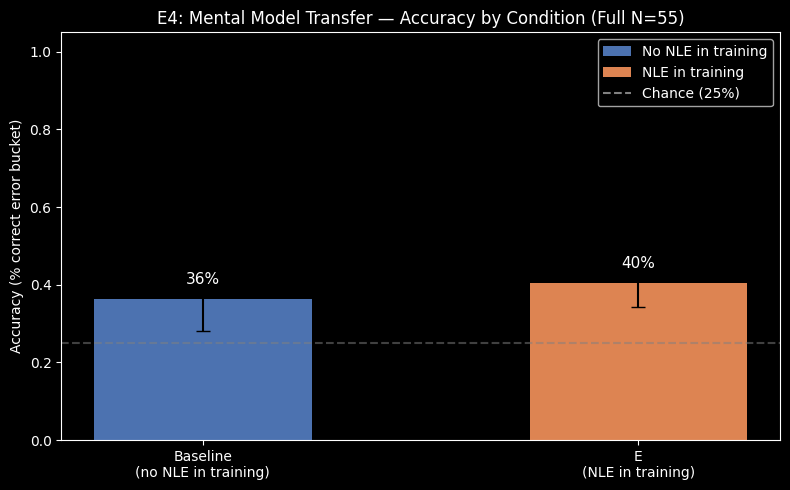

Figure saved: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E4/full_accuracy_by_condition.png


In [9]:
cond_order = ['Baseline', 'E']
colors = ['#4C72B0', '#DD8452']

accs = [acc.loc[c, 'accuracy'] if c in acc.index else 0 for c in cond_order]
lo = [acc.loc[c, 'ci_lo'] if c in acc.index else 0 for c in cond_order]
hi = [acc.loc[c, 'ci_hi'] if c in acc.index else 0 for c in cond_order]
errs = [[accs[i] - lo[i], hi[i] - accs[i]] for i in range(len(cond_order))]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Baseline\n(no NLE in training)', 'E\n(NLE in training)'],
              accs, color=colors, width=0.5,
              yerr=np.array(errs).T, capsize=5, ecolor='black')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy (% correct error bucket)')
mode_label = 'Pilot N=15' if PILOT_MODE else 'Full N=55'
ax.set_title(f'E4: Mental Model Transfer — Accuracy by Condition ({mode_label})')
ax.axhline(0.25, ls='--', color='gray', alpha=0.5, label='Chance (25%)')

for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{a:.0%}', ha='center', va='bottom', fontsize=11)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='No NLE in training'),
    Patch(facecolor='#DD8452', label='NLE in training'),
    plt.Line2D([0], [0], color='gray', ls='--', label='Chance (25%)')
]
ax.legend(handles=legend_elements)
plt.tight_layout()

fig_path = RESULTS_DIR / f'{"pilot" if PILOT_MODE else "full"}_accuracy_by_condition.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print(f'Figure saved: {fig_path}')

## 8. Summary

In [10]:
# Save summary table
summary = acc.copy()
summary['ci'] = [f"[{row.ci_lo:.1%}, {row.ci_hi:.1%}]" for _, row in summary.iterrows()]
summary['has_nle'] = [c in ['E'] for c in summary.index]
summary.to_csv(RESULTS_DIR / f'{"pilot" if PILOT_MODE else "full"}_summary.csv')

print('=== E4 Summary ===')
print(summary[['accuracy', 'n_total', 'ci', 'has_nle']].round(3))
print()

if PILOT_MODE:
    print('NEXT: Review pilot results. If effect size is sufficient, set PILOT_MODE = False and re-run.')
else:
    print('Full experiment complete.')
    print(f'Results: {CACHE_PATH}')
    print(f'Summary: {RESULTS_DIR / "full_summary.csv"}')

=== E4 Summary ===
           accuracy  n_total              ci  has_nle
condition                                            
Baseline      0.364      110  [28.0%, 45.7%]    False
E             0.405      220  [34.2%, 47.1%]     True

Full experiment complete.
Results: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E4/full_results.csv
Summary: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E4/full_summary.csv
